# Prompt Prediction Correlations

Compare sample-level predictions across prompt types (`B1`, `B2`, `C1`, `C2`, `C3`, `A`, `R`), across judges, and against the gold labels and studied task-model predictions, using every judge whose generations have been parsed into `data/predictions_*.csv`.

Class labels are categorical, so the reported metrics are exact agreement, Cohen's kappa, and multiclass Matthews correlation coefficient (MCC), not Pearson correlation.

Inputs:
* `data/predictions_{judge}.csv` – produced by `scripts/parse_generations.py` from `data/generations/*.jsonl`.
* `data/{task_model_slug}/local_elements_classes_*_n*.json` – gold labels and task-model predictions used to fill the `real_label` and `model_prediction` columns.

To keep the cross-family baseline invariant (B1 / B2 byte-identical across concepts / rationales / attributions), this notebook uses the harmonized `new_consim`, `attributions`, and `rationales` specifications with non-anonymized prompt types, excluding `old_consim` and `simulator_consim`.

## 1. Parameters

In [1]:
# Prediction CSVs to load. None -> every predictions_*.csv under data/.
PREDICTIONS_FILES = None

# Optional filters. None keeps every available value.
JUDGES = None
DATASETS = None
CLASSES_SUBSETS = None

# Best-method allow-list per prompt type. Only rows matching these will populate
# the corresponding column in the correlation matrix. Defaults match
# scripts/extract_best_prompts.py.
BEST_CONCEPT_METHOD = 'VanillaSAE'
BEST_CONCEPT_INTERPRETATION = 'topk'
BEST_ATTRIBUTION_METHOD = 'lime'
BEST_RATIONALE_METHODS = {'Qwen/Qwen3.5-2B'}

METRIC = 'mcc'          # 'mcc', 'kappa', or 'agreement'
MIN_PAIRED_SAMPLES = 2  # skip strata with fewer paired predictions
EXPORT_FIGURES = True

## 2. Load and Reshape Predictions

In [2]:
from collections import Counter
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.predictions import load_sample_metadata

DATA_DIR = REPO_ROOT / 'data'
EXPORT_DIR = REPO_ROOT / 'LaTeX-Simulatability-Shortcut' / 'plots'

PROMPT_TYPE_ALIAS = {'B1': 'B1', 'B2': 'B2', 'C1': 'C1', 'C2': 'C2', 'C3': 'C3', 'A1': 'A', 'R1': 'R'}
LABEL_COLUMNS = ['real_label', 'model_prediction', 'B1', 'B2', 'C1', 'C2', 'C3', 'A', 'R']
PROMPT_COLUMNS = ['B1', 'B2', 'C1', 'C2', 'C3', 'A', 'R']
DISPLAY_NAMES = {
    'real_label': 'Gold',
    'model_prediction': 'Model',
    'Qwen/Qwen3.5-9B': 'Qwen 3.5-9B',
    'microsoft/phi-4': 'Phi-4',
    'google/gemma-4-12B-it': 'Gemma 4-12B',
    'meta-llama/Llama-3.1-8B-Instruct': 'Llama 3.1-8B',
}

prediction_paths = (
    [Path(path) for path in PREDICTIONS_FILES]
    if PREDICTIONS_FILES
    else sorted(DATA_DIR.glob('predictions_*.csv'))
)
assert prediction_paths, 'No predictions_*.csv files found; run scripts/parse_generations.py first.'
print(f'Loading {len(prediction_paths)} predictions files...')
raw = pd.concat([pd.read_csv(path) for path in prediction_paths], ignore_index=True)
print(f'Total rows: {len(raw):,}')

# Latest-wins dedup on the full identity (judge, thinking + 9-field prompt key).
# Handles the case where the same key was parsed from multiple generation logs.
key_columns = ['judge', 'thinking', 'dataset', 'model', 'classes_subset', 'seed', 'method', 'nb_concepts', 'interpretation', 'prompt_type', 'specification']
before = len(raw)
raw = raw.drop_duplicates(subset=key_columns, keep='last').reset_index(drop=True)
print(f'After latest-wins dedup: {len(raw):,} (dropped {before - len(raw):,} duplicates)')

# Keep only prompt types the correlation matrix uses; exclude old/simulator
# consim (which don't share the byte-identical baseline invariant across
# families). New-ConSim concepts live under specification='new_consim';
# attributions and rationales use their own specifications with matching
# byte-identical B1/B2 baselines.
keep_specifications = {'new_consim', 'attributions', 'rationales'}
raw = raw[raw['specification'].isin(keep_specifications)].copy()
raw = raw[raw['prompt_type'].isin(PROMPT_TYPE_ALIAS)].copy()
print(f'After specification + non-anonymized filter: {len(raw):,}')
print(raw.groupby(['specification', 'prompt_type']).size())

Loading 4 predictions files...
Total rows: 219,307
After latest-wins dedup: 219,307 (dropped 0 duplicates)
After specification + non-anonymized filter: 64,050
specification  prompt_type
attributions   A1              7650
               B1              2300
               B2              2300
new_consim     B1              7150
               B2              7150
               C1             10000
               C2             10000
               C3             10000
rationales     B1              2300
               B2              2300
               R1              2900
dtype: int64


In [3]:
# Restrict each prompt type to its selected best method/config.
def keep_row(row):
    prompt_type = row['prompt_type']
    method = row['method']
    interpretation = row['interpretation'] if pd.notna(row['interpretation']) else None
    if prompt_type in {'B1', 'B2'}:
        return method == 'baseline'
    if prompt_type in {'C1', 'C2', 'C3'}:
        return method == BEST_CONCEPT_METHOD and interpretation == BEST_CONCEPT_INTERPRETATION
    if prompt_type == 'A1':
        return method == BEST_ATTRIBUTION_METHOD
    if prompt_type == 'R1':
        return method in BEST_RATIONALE_METHODS
    return False

raw = raw[raw.apply(keep_row, axis=1)].copy()
raw['prompt_column'] = raw['prompt_type'].map(PROMPT_TYPE_ALIAS)
print(f'After best-method filter: {len(raw):,}')

if JUDGES is not None:
    raw = raw[raw['judge'].isin(JUDGES)].copy()
if DATASETS is not None:
    raw = raw[raw['dataset'].isin(DATASETS)].copy()
if CLASSES_SUBSETS is not None:
    raw = raw[raw['classes_subset'].isin(CLASSES_SUBSETS)].copy()
print(f'After optional filters: {len(raw):,}')
print(f'Judges:   {sorted(raw["judge"].unique())}')
print(f'Datasets: {sorted(raw["dataset"].unique())}')

After best-method filter: 35,000
After optional filters: 35,000
Judges:   ['Qwen/Qwen3.5-9B', 'google/gemma-4-12B-it', 'meta-llama/Llama-3.1-8B-Instruct', 'microsoft/phi-4']
Datasets: ['AG', 'BIOS', 'E', 'GE', 'IMDB', 'RT']


In [4]:
# Melt sample columns to long form, keeping only samples that exist for the row
# (there are up to MAX_SAMPLES columns; unused ones are empty).
pred_columns = [c for c in raw.columns if c.startswith('pred_')]
id_columns = ['judge', 'thinking', 'dataset', 'model', 'classes_subset', 'seed', 'cache_n', 'prompt_column']
long = raw.melt(id_vars=id_columns, value_vars=pred_columns, var_name='sample_col', value_name='prediction')
long['sample_index'] = long['sample_col'].str.removeprefix('pred_').astype(int)
long = long.dropna(subset=['prediction']).copy()
long['prediction'] = pd.to_numeric(long['prediction'], errors='coerce').astype('Int64')
long = long.dropna(subset=['prediction'])  # drop any left-over invalid rows
long = long.drop(columns=['sample_col'])
print(f'Long-form rows: {len(long):,}')
display(long.head())

Long-form rows: 697,826


,judge,thinking,dataset,model,classes_subset,seed,cache_n,prompt_column,prediction,sample_index
0,Qwen/Qwen3.5-9B,False,RT,RB,"[0, 1]",0,40.0,B1,0,0
1,Qwen/Qwen3.5-9B,False,RT,RB,"[0, 1]",0,40.0,B2,0,0
2,Qwen/Qwen3.5-9B,False,RT,RB,"[0, 1]",1,40.0,B1,0,0
3,Qwen/Qwen3.5-9B,False,RT,RB,"[0, 1]",1,40.0,B2,0,0
4,Qwen/Qwen3.5-9B,False,RT,RB,"[0, 1]",2,40.0,B1,0,0


In [5]:
# Build per-sample metadata (real_label, model_prediction) once from the
# local_elements cache. Keyed by (dataset, classes_subset, seed, cache_n).
metadata_rows = []
unique_caches = long[['dataset', 'classes_subset', 'seed', 'cache_n']].dropna().drop_duplicates()
unique_caches['cache_n'] = unique_caches['cache_n'].astype(int)
print(f'Loading metadata for {len(unique_caches)} (dataset, classes_subset, seed, cache_n) tuples...')
for dataset, classes_subset, seed, cache_n in unique_caches.itertuples(index=False, name=None):
    for sample in load_sample_metadata(dataset, classes_subset, int(seed), int(cache_n), data_root=REPO_ROOT):
        metadata_rows.append({
            'dataset': dataset,
            'classes_subset': classes_subset,
            'seed': int(seed),
            'cache_n': int(cache_n),
            **sample,
        })
sample_metadata = pd.DataFrame(metadata_rows)
print(f'Sample metadata rows: {len(sample_metadata):,}')
display(sample_metadata.head())

Loading metadata for 600 (dataset, classes_subset, seed, cache_n) tuples...
Sample metadata rows: 12,000


,dataset,classes_subset,seed,cache_n,sample_index,test_index,real_label,task_model_prediction
0,RT,"[0, 1]",0,40,0,918,0,0
1,RT,"[0, 1]",0,40,1,50,1,0
2,RT,"[0, 1]",0,40,2,544,0,1
3,RT,"[0, 1]",0,40,3,712,0,0
4,RT,"[0, 1]",0,40,4,1060,0,0


In [6]:
# One row per (judge, thinking, dataset, model, classes_subset, seed, sample_index)
# with one column per prompt type. Latest-wins if there are still duplicates.
row_key_columns = ['judge', 'thinking', 'dataset', 'model', 'classes_subset', 'seed', 'sample_index']
wide = (
    long.groupby(row_key_columns + ['prompt_column'], as_index=False)['prediction']
        .last()
        .pivot(index=row_key_columns, columns='prompt_column', values='prediction')
        .reset_index()
)
wide = wide.merge(
    sample_metadata[['dataset', 'classes_subset', 'seed', 'sample_index', 'real_label', 'task_model_prediction']],
    on=['dataset', 'classes_subset', 'seed', 'sample_index'],
    how='left',
)
wide = wide.rename(columns={'task_model_prediction': 'model_prediction'})
for column in LABEL_COLUMNS:
    if column not in wide.columns:
        wide[column] = pd.NA
    wide[column] = pd.to_numeric(wide[column], errors='coerce').astype('Int64')
print(f'Wide rows: {len(wide):,}')
display(wide.head())

Wide rows: 45,999


,judge,thinking,dataset,model,classes_subset,seed,sample_index,A,B1,B2,C1,C2,C3,R,real_label,model_prediction
0,Qwen/Qwen3.5-9B,False,AG,DB,"[0, 1, 2, 3]",0,0,1,1,1,1,1,0,0,0,0
1,Qwen/Qwen3.5-9B,False,AG,DB,"[0, 1, 2, 3]",0,1,2,2,2,2,2,2,2,2,3
2,Qwen/Qwen3.5-9B,False,AG,DB,"[0, 1, 2, 3]",0,2,1,1,1,0,1,1,1,1,2
3,Qwen/Qwen3.5-9B,False,AG,DB,"[0, 1, 2, 3]",0,3,0,0,0,0,0,0,0,0,0
4,Qwen/Qwen3.5-9B,False,AG,DB,"[0, 1, 2, 3]",0,4,0,0,0,0,0,0,0,0,3


## 3. Coverage

In [7]:
rows_by_cell = wide.groupby(['judge', 'dataset'], dropna=False).size().rename('n_rows').reset_index()
valid_rates = (
    wide.groupby(['judge', 'dataset'], dropna=False)[LABEL_COLUMNS]
        .agg(lambda values: values.notna().mean())
        .reset_index()
)
display(rows_by_cell)
display(valid_rates)

,judge,dataset,n_rows
0,Qwen/Qwen3.5-9B,AG,1000
1,Qwen/Qwen3.5-9B,BIOS,4000
2,Qwen/Qwen3.5-9B,E,1000
3,Qwen/Qwen3.5-9B,GE,4000
4,Qwen/Qwen3.5-9B,IMDB,1000
5,Qwen/Qwen3.5-9B,RT,1000
6,google/gemma-4-12B-it,AG,1000
7,google/gemma-4-12B-it,BIOS,4000
8,google/gemma-4-12B-it,E,1000
9,google/gemma-4-12B-it,GE,3000


,judge,dataset,real_label,model_prediction,B1,B2,C1,C2,C3,A,R
0,Qwen/Qwen3.5-9B,AG,1,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Qwen/Qwen3.5-9B,BIOS,1,1,0.999500,1.000000,0.999750,1.000000,1.000000,1.000000,1.000000
2,Qwen/Qwen3.5-9B,E,1,1,0.995000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Qwen/Qwen3.5-9B,GE,1,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,Qwen/Qwen3.5-9B,IMDB,1,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,Qwen/Qwen3.5-9B,RT,1,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,google/gemma-4-12B-it,AG,1,1,0.998000,0.999000,0.989000,0.989000,0.986000,0.996000,0.989000
7,google/gemma-4-12B-it,BIOS,1,1,0.996500,0.996000,0.975500,0.991500,0.989750,0.992250,0.990000
8,google/gemma-4-12B-it,E,1,1,0.990000,0.992000,0.980000,0.986000,0.975000,0.992000,0.978000
9,google/gemma-4-12B-it,GE,1,1,0.994000,0.994333,0.999333,0.993000,0.981667,0.980667,0.991333


## 4. Categorical Association Metrics

All three metrics treat class ids as **unordered categorical labels**: they only ever compare pairs with `l == r` and use the labels as keys into a `Counter`. No arithmetic (differences, products) is ever taken on the class ids themselves, so results are invariant under any relabeling of the classes.

* `agreement` — fraction of pairs with `l == r`.
* `kappa` — Cohen's kappa: `(observed - expected) / (1 - expected)`, where `expected` is chance agreement from the marginal distributions.
* `mcc` — Gorodkin's multiclass MCC computed from the confusion-matrix marginals; the natural categorical generalisation of the binary Matthews correlation.

In [8]:
def paired_confusion(left, right):
    paired = pd.concat([left, right], axis=1).dropna()
    counts = Counter((int(a), int(b)) for a, b in paired.itertuples(index=False, name=None))
    return counts, len(paired)

def exact_agreement(confusion):
    total = sum(confusion.values())
    return sum(count for (l, r), count in confusion.items() if l == r) / total if total else np.nan

def cohen_kappa(confusion):
    total = sum(confusion.values())
    if not total:
        return np.nan
    left_marginal, right_marginal = Counter(), Counter()
    for (l, r), count in confusion.items():
        left_marginal[l] += count
        right_marginal[r] += count
    labels = left_marginal.keys() | right_marginal.keys()
    observed = exact_agreement(confusion)
    expected = sum(left_marginal[label] * right_marginal[label] for label in labels) / total**2
    return (observed - expected) / (1 - expected) if not math.isclose(expected, 1.0) else np.nan

def multiclass_mcc(confusion):
    total = sum(confusion.values())
    if not total:
        return np.nan
    left_marginal, right_marginal = Counter(), Counter()
    correct = 0
    for (l, r), count in confusion.items():
        left_marginal[l] += count
        right_marginal[r] += count
        correct += count if l == r else 0
    labels = left_marginal.keys() | right_marginal.keys()
    covariance = correct * total - sum(left_marginal[label] * right_marginal[label] for label in labels)
    left_variance = total**2 - sum(count**2 for count in left_marginal.values())
    right_variance = total**2 - sum(count**2 for count in right_marginal.values())
    denominator = math.sqrt(left_variance * right_variance)
    return covariance / denominator if denominator else np.nan

METRIC_FUNCTIONS = {'agreement': exact_agreement, 'kappa': cohen_kappa, 'mcc': multiclass_mcc}
assert METRIC in METRIC_FUNCTIONS, f'Unknown metric: {METRIC}'

def association_matrix(frame, label_columns=LABEL_COLUMNS, strata_columns=('classes_subset',)):
    matrix = pd.DataFrame(np.nan, index=label_columns, columns=label_columns)
    pair_counts = pd.DataFrame(0, index=label_columns, columns=label_columns, dtype=int)
    stratum_counts = pd.DataFrame(0, index=label_columns, columns=label_columns, dtype=int)
    group_key = strata_columns[0] if len(strata_columns) == 1 else list(strata_columns)
    for left in label_columns:
        for right in label_columns:
            per_stratum_scores = []
            total_pairs = 0
            for _stratum_key, stratum in frame.groupby(group_key, dropna=False):
                confusion, n_pairs = paired_confusion(stratum[left], stratum[right])
                total_pairs += n_pairs
                if n_pairs < MIN_PAIRED_SAMPLES:
                    continue
                score = 1.0 if left == right else METRIC_FUNCTIONS[METRIC](confusion)
                if not np.isnan(score):
                    per_stratum_scores.append(score)
            pair_counts.loc[left, right] = total_pairs
            stratum_counts.loc[left, right] = len(per_stratum_scores)
            if per_stratum_scores:
                # Equal-weight mean over strata: each stratum contributes once,
                # so a stratum with many pairs does not dominate.
                matrix.loc[left, right] = float(np.mean(per_stratum_scores))
    return matrix, pair_counts, stratum_counts

def plot_matrix(matrix, title, output_slug=None):
    labels = [DISPLAY_NAMES.get(c, c) for c in matrix.index]
    values = matrix.to_numpy(dtype=float)
    vmin = 0 if METRIC == 'agreement' else -1
    size = max(6.5, 0.75 * len(labels))
    fig, axis = plt.subplots(figsize=(size, size))
    image = axis.imshow(values, cmap='coolwarm', vmin=vmin, vmax=1)
    axis.set_xticks(range(len(labels)), labels=labels, rotation=45, ha='right')
    axis.set_yticks(range(len(labels)), labels=labels)
    axis.set_title(title)
    for row in range(len(labels)):
        for column in range(len(labels)):
            value = values[row, column]
            if not np.isnan(value):
                axis.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=9, color='black')
    fig.tight_layout()
    if EXPORT_FIGURES and output_slug is not None:
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(EXPORT_DIR / f'prediction_correlations_{METRIC}_{output_slug}.pdf', bbox_inches='tight')
    plt.show()

## 5. Summary Matrix (All Judges and Datasets)

Each cell of the matrix is computed separately for every **(`judge`, `dataset`, `classes_subset`) stratum** and then **averaged with equal weight** across strata. Pooling strata into a single confusion matrix would inject shared judge, dataset, and class-subset signals into every pair of prompt columns.

MCC | all judges | all datasets
(each cell = mean over 46 judge/dataset/classes_subset strata at most)


,Gold,Model,B1,B2,C1,C2,C3,A,R
Gold,1.000000,0.222263,0.449940,0.447476,0.445072,0.431004,0.415158,0.414035,0.432336
Model,0.222263,1.000000,0.421423,0.456234,0.452528,0.468253,0.454605,0.434047,0.436947
B1,0.449940,0.421423,1.000000,0.710895,0.714753,0.660460,0.633412,0.660149,0.690155
B2,0.447476,0.456234,0.710895,1.000000,0.684920,0.784620,0.730569,0.780325,0.811456
C1,0.445072,0.452528,0.714753,0.684920,1.000000,0.727110,0.701137,0.651348,0.670557
C2,0.431004,0.468253,0.660460,0.784620,0.727110,1.000000,0.809354,0.740375,0.741245
C3,0.415158,0.454605,0.633412,0.730569,0.701137,0.809354,1.000000,0.730453,0.717351
A,0.414035,0.434047,0.660149,0.780325,0.651348,0.740375,0.730453,1.000000,0.778422
R,0.432336,0.436947,0.690155,0.811456,0.670557,0.741245,0.717351,0.778422,1.000000


Pair counts


,Gold,Model,B1,B2,C1,C2,C3,A,R
Gold,45999,45999,45718,45911,45789,45888,45827,45848,45834
Model,45999,45999,45718,45911,45789,45888,45827,45848,45834
B1,45718,45718,45718,45641,45553,45620,45557,45580,45561
B2,45911,45911,45641,45911,45711,45804,45743,45767,45748
C1,45789,45789,45553,45711,45789,45694,45627,45644,45628
C2,45888,45888,45620,45804,45694,45888,45726,45742,45723
C3,45827,45827,45557,45743,45627,45726,45827,45681,45665
A,45848,45848,45580,45767,45644,45742,45681,45848,45692
R,45834,45834,45561,45748,45628,45723,45665,45692,45834


Number of (judge, dataset, classes_subset) strata averaged


,Gold,Model,B1,B2,C1,C2,C3,A,R
Gold,46,46,46,46,46,46,46,46,46
Model,46,46,46,46,46,46,46,46,46
B1,46,46,46,46,46,46,46,46,46
B2,46,46,46,46,46,46,46,46,46
C1,46,46,46,46,46,46,46,46,46
C2,46,46,46,46,46,46,46,46,46
C3,46,46,46,46,46,46,46,46,46
A,46,46,46,46,46,46,46,46,46
R,46,46,46,46,46,46,46,46,46


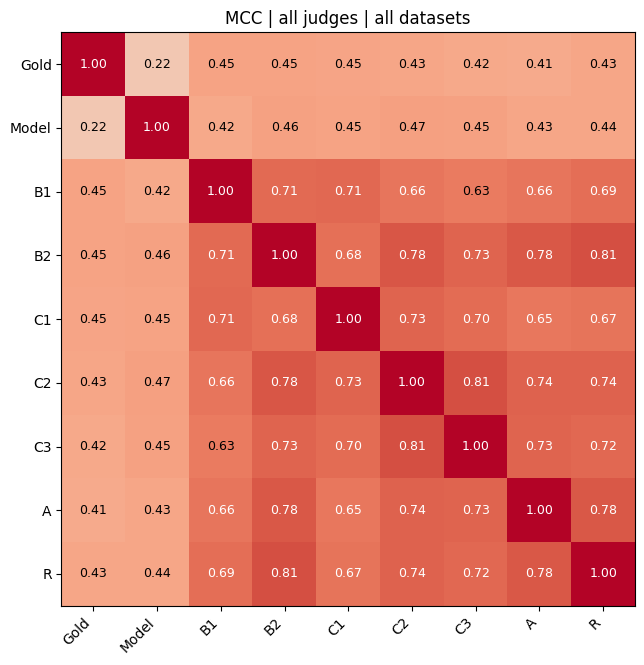

In [9]:
summary_matrix, summary_pair_counts, summary_stratum_counts = association_matrix(
    wide, strata_columns=('judge', 'dataset', 'classes_subset')
)
print(f'{METRIC.upper()} | all judges | all datasets')
print(f'(each cell = mean over {summary_stratum_counts.max().max()} judge/dataset/classes_subset strata at most)')
display(summary_matrix.rename(index=DISPLAY_NAMES, columns=DISPLAY_NAMES))
print('Pair counts')
display(summary_pair_counts.rename(index=DISPLAY_NAMES, columns=DISPLAY_NAMES))
print('Number of (judge, dataset, classes_subset) strata averaged')
display(summary_stratum_counts.rename(index=DISPLAY_NAMES, columns=DISPLAY_NAMES))
plot_matrix(summary_matrix, f'{METRIC.upper()} | all judges | all datasets', output_slug='summary')

## 6. Per (Judge, Dataset) Matrices

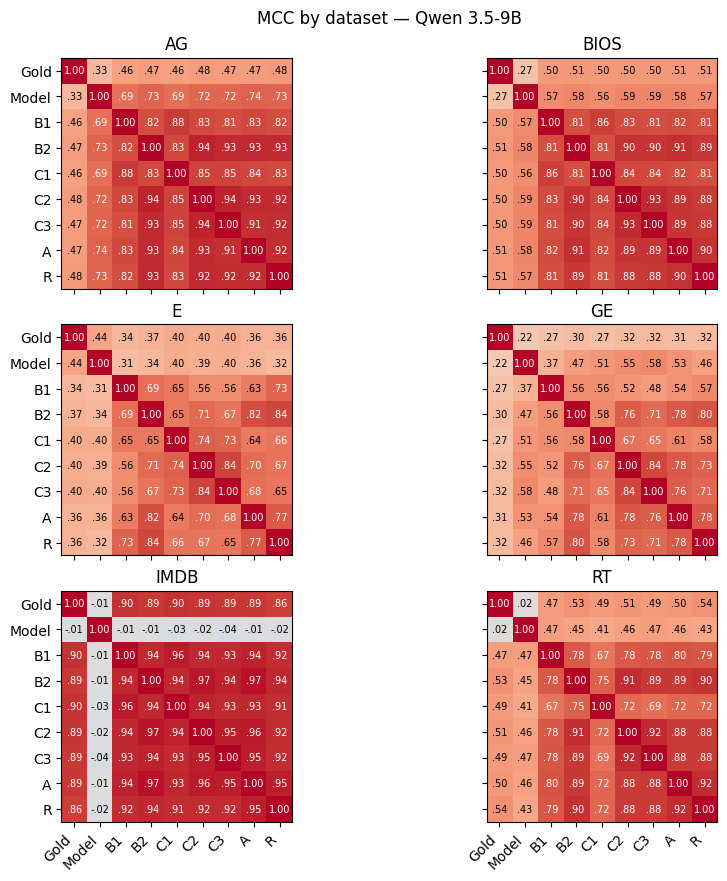

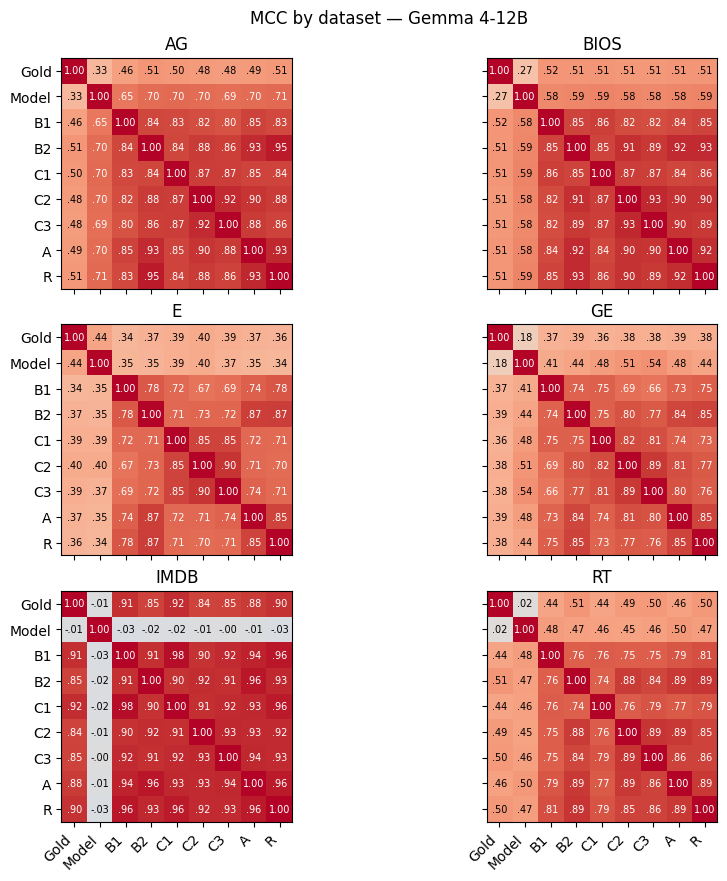

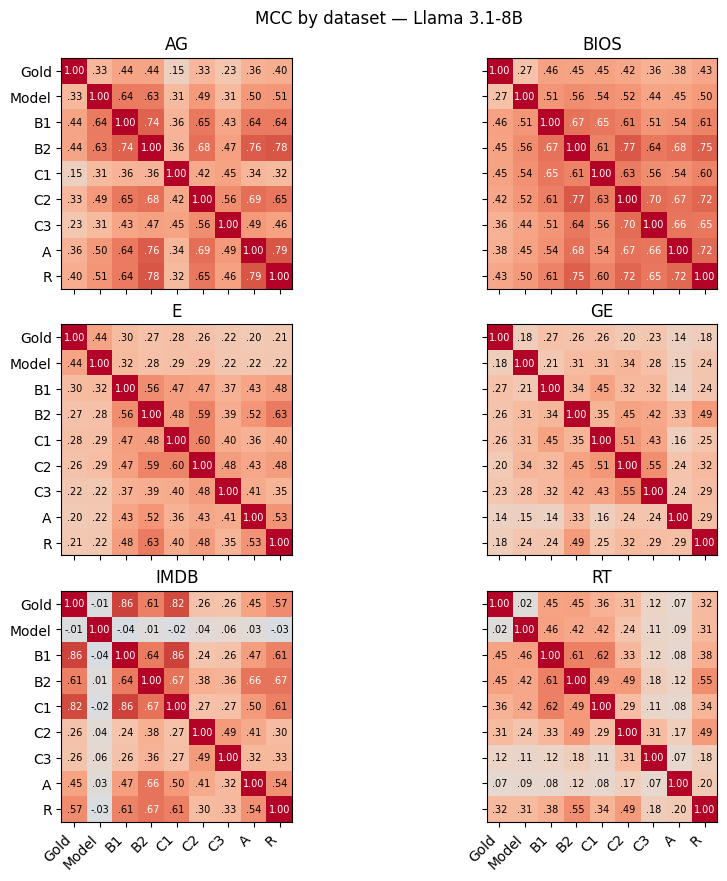

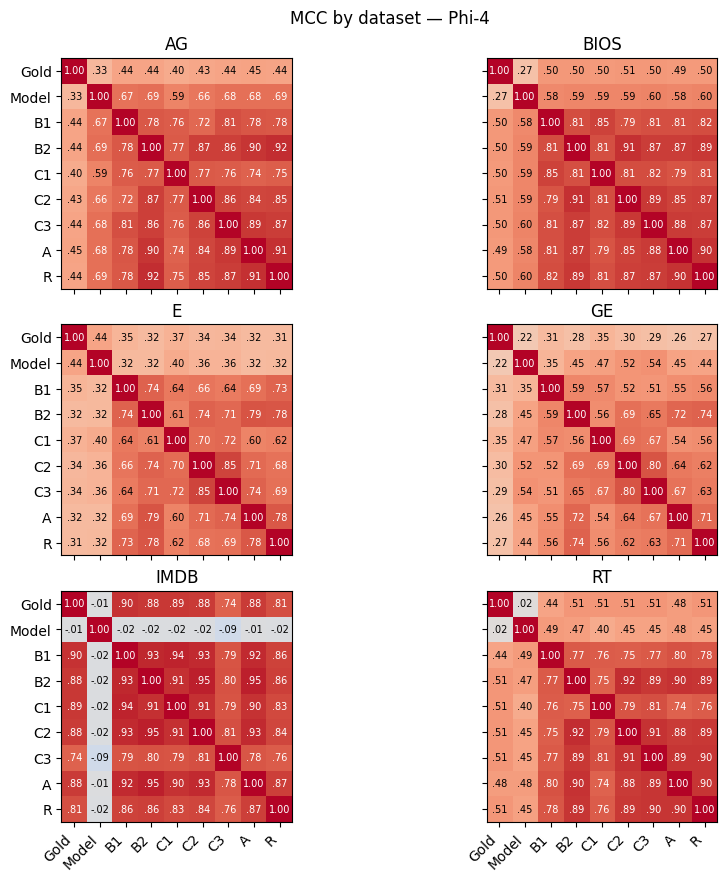

In [10]:
matrices = {}
pair_count_matrices = {}
stratum_count_matrices = {}
for (judge, thinking, dataset), group in wide.groupby(['judge', 'thinking', 'dataset'], dropna=False):
    key = (judge, bool(thinking), dataset)
    matrices[key], pair_count_matrices[key], stratum_count_matrices[key] = association_matrix(group)

def plot_judge_matrices(judge, thinking):
    datasets = sorted(dataset for j, t, dataset in matrices if j == judge and t == thinking)
    if not datasets:
        return
    ncols = min(2, len(datasets))
    nrows = math.ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.4 * nrows), squeeze=False, constrained_layout=True)
    labels = [DISPLAY_NAMES.get(c, c) for c in LABEL_COLUMNS]
    vmin = 0 if METRIC == 'agreement' else -1
    image = None
    for panel_index, (axis, dataset) in enumerate(zip(axes.flat, datasets)):
        values = matrices[(judge, thinking, dataset)].to_numpy(dtype=float)
        image = axis.imshow(values, cmap='coolwarm', vmin=vmin, vmax=1)
        axis.set_title(dataset)
        panel_row, panel_col = divmod(panel_index, ncols)
        axis.set_xticks(range(len(labels)))
        axis.set_yticks(range(len(labels)))
        axis.set_xticklabels(labels if panel_row == nrows - 1 else [], rotation=45, ha='right')
        axis.set_yticklabels(labels if panel_col == 0 else [])
        for row in range(len(labels)):
            for column in range(len(labels)):
                value = values[row, column]
                if not np.isnan(value):
                    text = f'{value:.2f}'.replace('0.', '.').replace('-.', '-.')
                    axis.text(column, row, text, ha='center', va='center', fontsize=8, color='black')
    for axis in axes.flat[len(datasets):]:
        axis.set_visible(False)
    judge_display = DISPLAY_NAMES.get(judge, judge)
    thinking_label = ' (thinking)' if thinking else ''
    fig.suptitle(f'{METRIC.upper()} by dataset — {judge_display}{thinking_label}')
    if EXPORT_FIGURES:
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        slug = judge.replace('/', '_')
        thinking_slug = '_thinking' if thinking else ''
        fig.savefig(EXPORT_DIR / f'prediction_correlations_{METRIC}_{slug}{thinking_slug}.pdf', bbox_inches='tight')
    plt.show()

for judge, thinking in wide[['judge', 'thinking']].drop_duplicates().sort_values(['judge', 'thinking']).itertuples(index=False, name=None):
    plot_judge_matrices(judge, bool(thinking))

## 7. Prompt Association with Gold and Task-Model Labels

In [11]:
target_rows = []
for (judge, thinking, dataset), matrix in matrices.items():
    for prompt_type in PROMPT_COLUMNS:
        target_rows.append({
            'judge': judge,
            'thinking': thinking,
            'dataset': dataset,
            'prompt_type': prompt_type,
            f'{METRIC}_with_gold': matrix.loc[prompt_type, 'real_label'],
            f'{METRIC}_with_task_model': matrix.loc[prompt_type, 'model_prediction'],
            'n_with_gold': pair_count_matrices[(judge, thinking, dataset)].loc[prompt_type, 'real_label'],
            'n_with_task_model': pair_count_matrices[(judge, thinking, dataset)].loc[prompt_type, 'model_prediction'],
        })
target_summary = pd.DataFrame(target_rows).sort_values(['judge', 'thinking', 'dataset', 'prompt_type'])
display(target_summary)

,judge,thinking,dataset,prompt_type,mcc_with_gold,mcc_with_task_model,n_with_gold,n_with_task_model
5,Qwen/Qwen3.5-9B,False,AG,A,0.470173,0.741027,1000,1000
0,Qwen/Qwen3.5-9B,False,AG,B1,0.457179,0.685117,1000,1000
1,Qwen/Qwen3.5-9B,False,AG,B2,0.474505,0.733151,1000,1000
2,Qwen/Qwen3.5-9B,False,AG,C1,0.462922,0.691017,1000,1000
3,Qwen/Qwen3.5-9B,False,AG,C2,0.477474,0.722325,1000,1000
...,...,...,...,...,...,...,...,...
162,microsoft/phi-4,False,RT,B2,0.514600,0.468888,1000,1000
163,microsoft/phi-4,False,RT,C1,0.514175,0.403954,1000,1000
164,microsoft/phi-4,False,RT,C2,0.509941,0.451223,1000,1000
165,microsoft/phi-4,False,RT,C3,0.514780,0.452245,1000,1000


## 8. Correlation Between Judges

This matrix compares judge predictions and includes the gold labels and studied task-model predictions. Each observation is one selected `(prompt_type, sample)` prediction. Association is computed separately for every **(`dataset`, `classes_subset`, `prompt_type`) stratum**, then averaged with equal weight across valid strata. This prevents shared dataset, class-subset, or prompt-type distributions from artificially increasing correlations. Pairwise-complete observations are used when a judge is missing a prompt or produced an invalid answer.

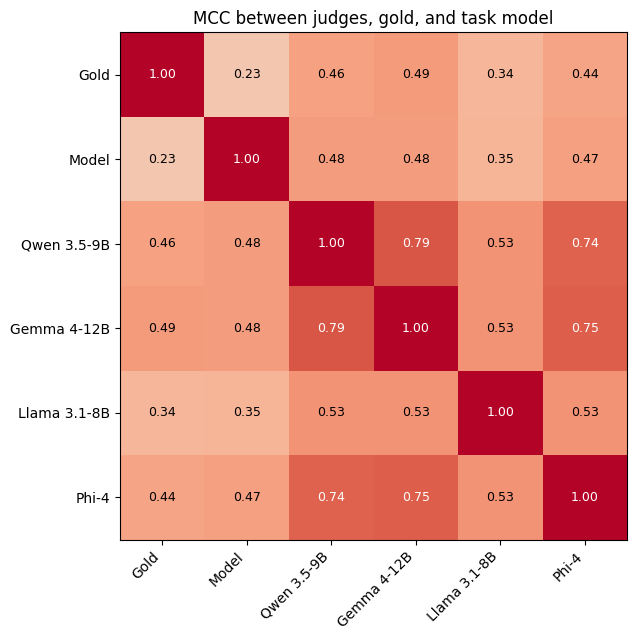

In [12]:
# Stack prompt types so each judge has one prediction column. Thinking and
# non-thinking runs are kept as separate judge labels when both are present.
sample_key = ['dataset', 'model', 'classes_subset', 'seed', 'sample_index']
judge_long = wide.melt(
    id_vars=['judge', 'thinking', *sample_key],
    value_vars=PROMPT_COLUMNS,
    var_name='prompt_type',
    value_name='prediction',
)
judge_long['judge_label'] = judge_long['judge'] + np.where(
    judge_long['thinking'].astype(bool), ' [thinking]', ''
)
judge_long = judge_long.dropna(subset=['prediction']).copy()

judge_wide = (
    judge_long.pivot_table(
        index=[*sample_key, 'prompt_type'],
        columns='judge_label',
        values='prediction',
        aggfunc='last',
    )
    .reset_index()
)

targets = (
    wide[[*sample_key, 'real_label', 'model_prediction']]
    .drop_duplicates(subset=sample_key, keep='last')
)
judge_wide = judge_wide.merge(targets, on=sample_key, how='left')
judge_columns = sorted(judge_long['judge_label'].unique())
judge_matrix_columns = ['real_label', 'model_prediction', *judge_columns]
for column in judge_matrix_columns:
    judge_wide[column] = pd.to_numeric(judge_wide[column], errors='coerce').astype('Int64')

judge_matrix, judge_pair_counts, judge_stratum_counts = association_matrix(
    judge_wide,
    label_columns=judge_matrix_columns,
    strata_columns=('dataset', 'classes_subset', 'prompt_type'),
)
plot_matrix(
    judge_matrix,
    f'{METRIC.upper()} between judges, gold, and task model',
    output_slug='judges_summary',
)